In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [60]:
# Load data
data_dir = Path('/home/niclasflehmig/VisualCodeProjects/H2-dispersion-model/data')
df = pd.read_csv(data_dir / 'unified_raw.csv')

In [4]:
df.describe()

,time,mass_flow,sensor_id,x,y,z,h2_volume_fraction
count,296665.000000,296665.000000,296665.000000,296665.000000,296665.000000,296665.000000,2.966650e+05
mean,108.789936,0.384129,15.496257,0.460740,2.169132,0.485293,4.215154e-02
std,68.234622,0.335607,8.800244,0.200273,1.612818,0.312835,5.203003e-02
min,0.000000,0.029177,1.000000,0.000000,0.000000,0.000000,1.211063e-13
25%,50.490000,0.091000,8.000000,0.460000,0.260000,0.270000,1.573871e-03
50%,101.599474,0.434385,15.000000,0.470000,2.220000,0.520000,1.129484e-02
75%,166.230000,0.484407,23.000000,0.470000,3.540000,0.800000,8.063445e-02
max,239.990000,1.270000,30.000000,0.900000,4.680000,0.800000,3.082763e-01


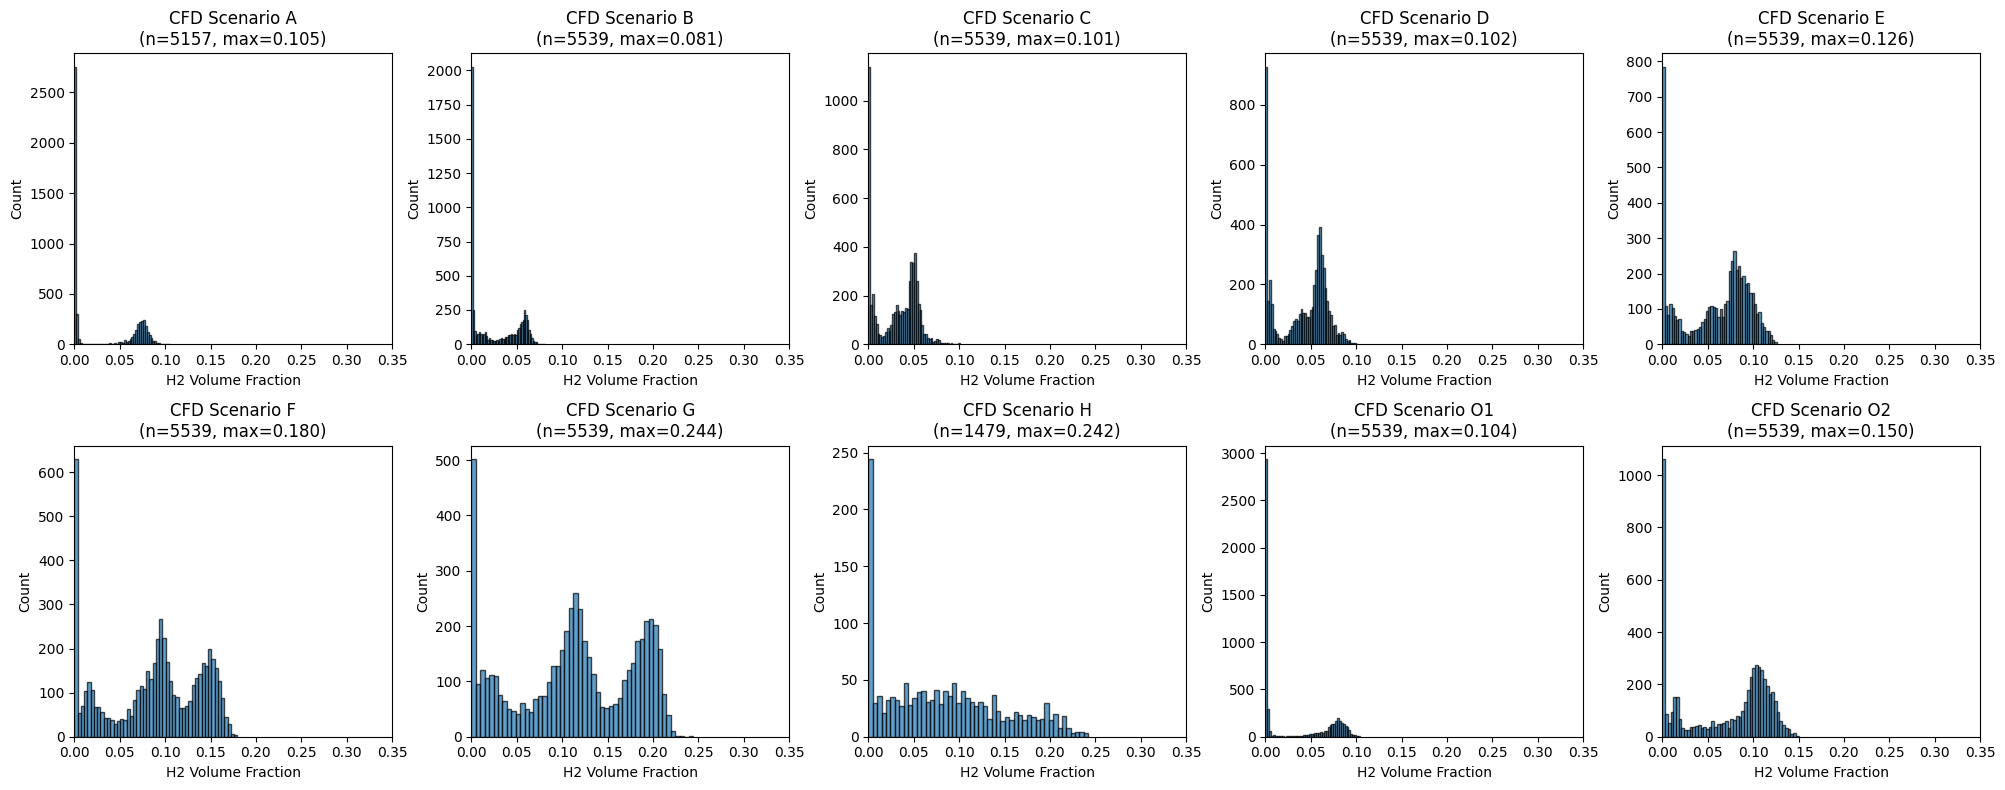

In [5]:
# CFD scenario histograms
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

cfd_scenarios = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'O1', 'O2']

for idx, scenario in enumerate(cfd_scenarios):
    ax = axes[idx]
    df_scenario = df[(df['source'] == 'cfd') & (df['scenario'] == scenario)]
    
    ax.hist(df_scenario['h2_volume_fraction'], bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(f'CFD Scenario {scenario}\n(n={len(df_scenario)}, max={df_scenario["h2_volume_fraction"].max():.3f})')
    ax.set_xlabel('H2 Volume Fraction')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 0.35)

plt.tight_layout()
plt.savefig(data_dir / 'cfd_histograms.png', dpi=150)
plt.show()

In [13]:
df_scenario = df[(df['source'] == 'cfd') & (df['scenario'] == 'A')]
df_scenario['h2_volume_fraction'].head()

0    1.000000e-08
1    1.000000e-08
2    9.952579e-04
3    6.282511e-03
4    1.797501e-02
Name: h2_volume_fraction, dtype: float64

In [11]:
log_h2 = np.log(df_scenario['h2_volume_fraction'] + 1e-8)

In [12]:
log_h2

0      -17.727534
1      -17.727534
2       -6.912499
3       -5.069984
4       -4.018772
          ...    
5152   -10.223018
5153   -10.266334
5154   -10.204625
5155   -10.284277
5156   -10.147832
Name: h2_volume_fraction, Length: 5157, dtype: float64

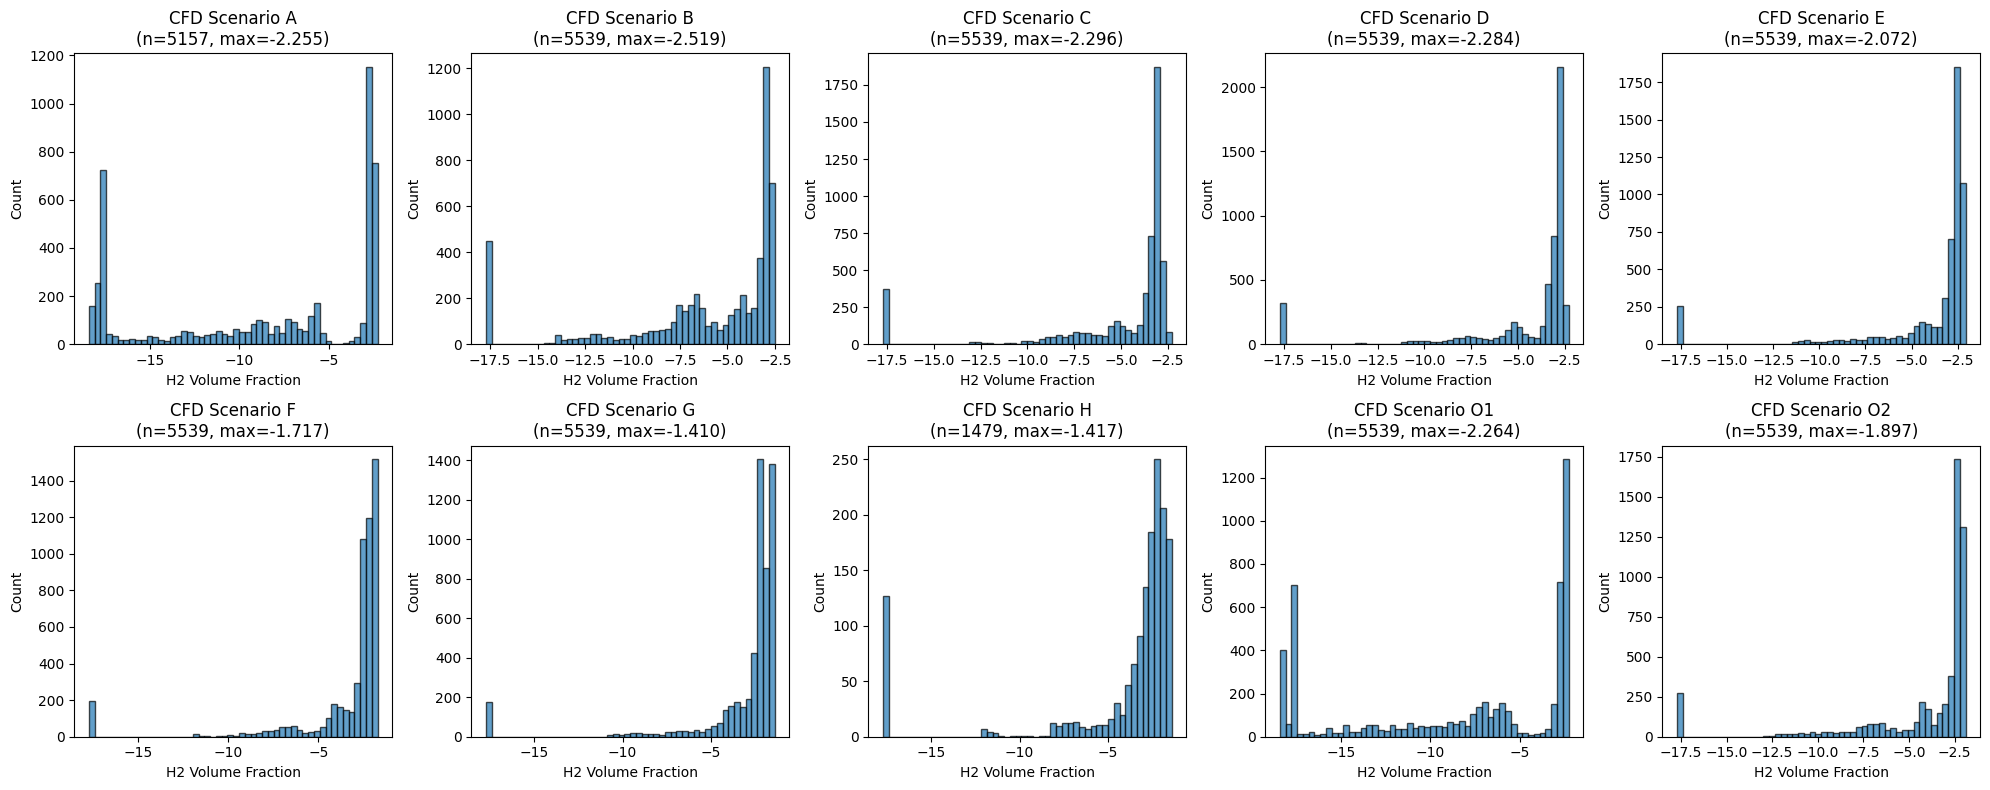

In [14]:
# CFD scenario histograms
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

cfd_scenarios = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'O1', 'O2']

for idx, scenario in enumerate(cfd_scenarios):
    ax = axes[idx]
    df_scenario = df[(df['source'] == 'cfd') & (df['scenario'] == scenario)]
    log_h2 = np.log(df_scenario['h2_volume_fraction'] + 1e-8)

    ax.hist(log_h2, bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(f'CFD Scenario {scenario}\n(n={len(df_scenario)}, max={log_h2.max():.3f})')
    ax.set_xlabel('H2 Volume Fraction')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(data_dir / 'cfd_histograms.png', dpi=150)
plt.show()

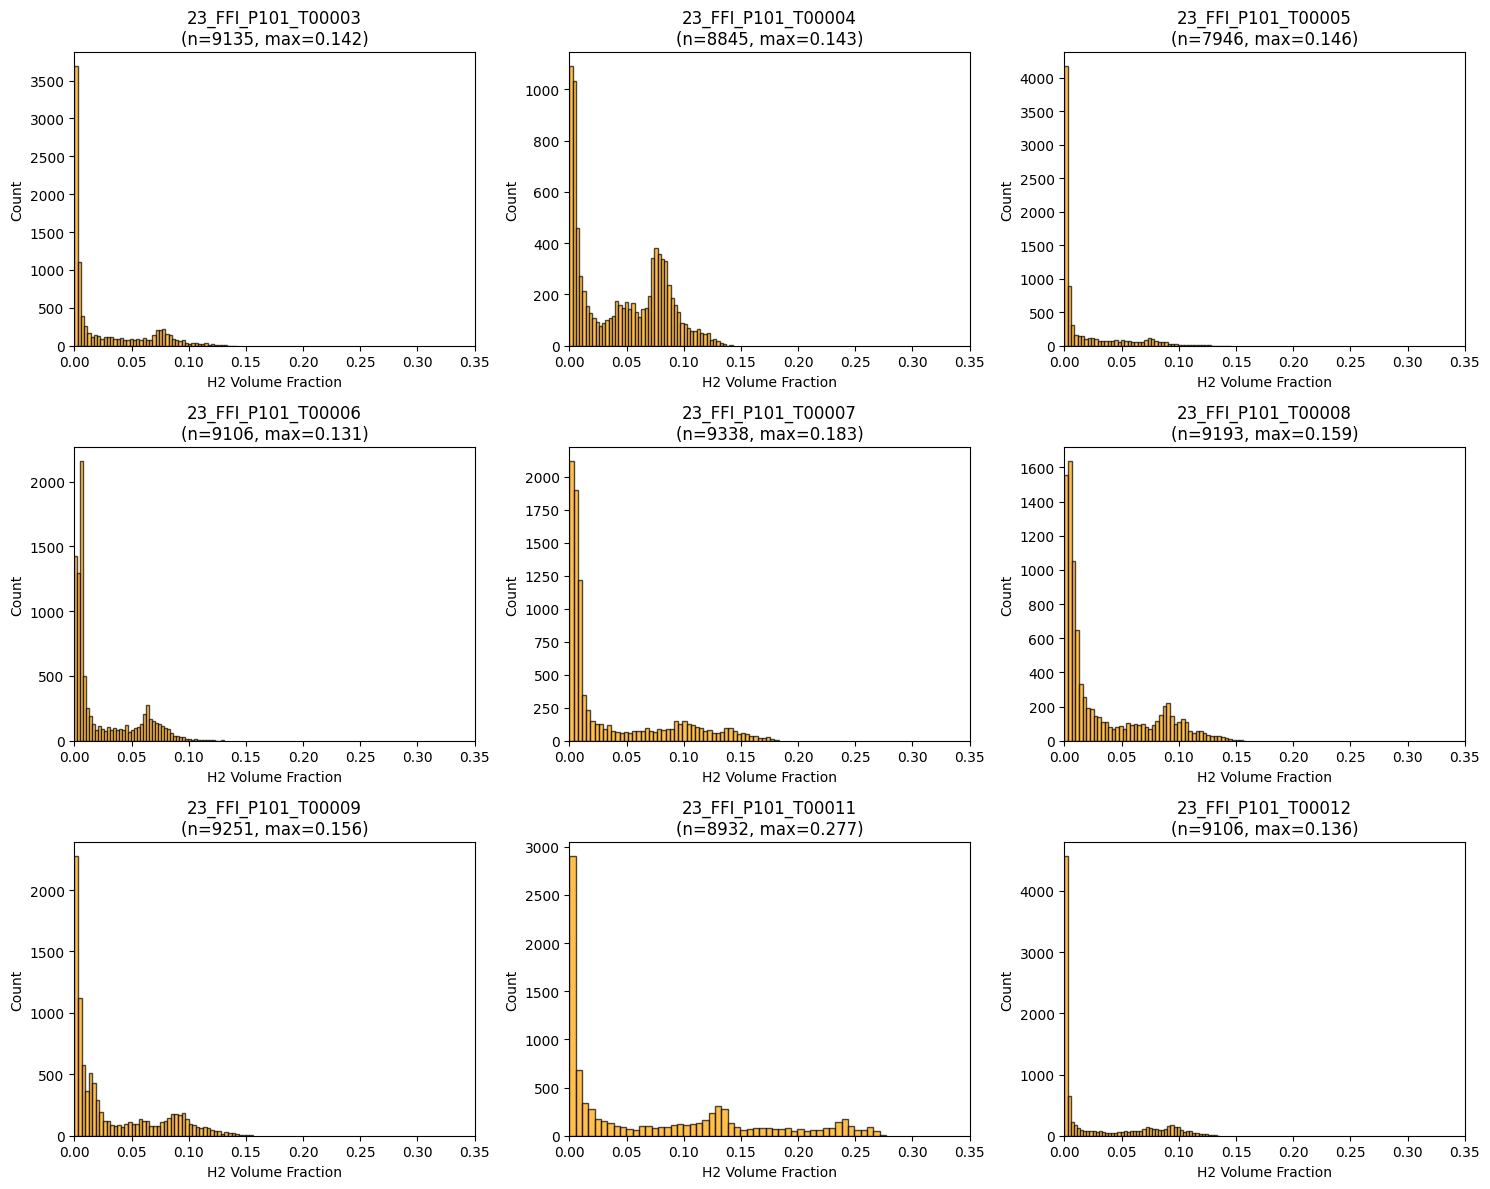

In [33]:
# Experiment histograms (sample of 9)
exp_ids = df[df['source'] == 'experiment']['experiment_id'].unique()[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, exp_id in enumerate(exp_ids):
    ax = axes[idx]
    df_exp = df[df['experiment_id'] == exp_id]
    
    ax.hist(df_exp['h2_volume_fraction'], bins=50, alpha=0.7, edgecolor='black', color='orange')
    ax.set_title(f'{exp_id}\n(n={len(df_exp)}, max={df_exp["h2_volume_fraction"].max():.3f})')
    ax.set_xlabel('H2 Volume Fraction')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 0.35)

plt.tight_layout()
plt.savefig(data_dir / 'experiment_histograms.png', dpi=150)
plt.show()

Correlation Matrix:
           mass_flow   time      x      y      z
mass_flow      1.000 -0.028  0.001 -0.001  0.001
time          -0.028  1.000  0.001 -0.001  0.001
x              0.001  0.001  1.000  0.006  0.034
y             -0.001 -0.001  0.006  1.000  0.135
z              0.001  0.001  0.034  0.135  1.000


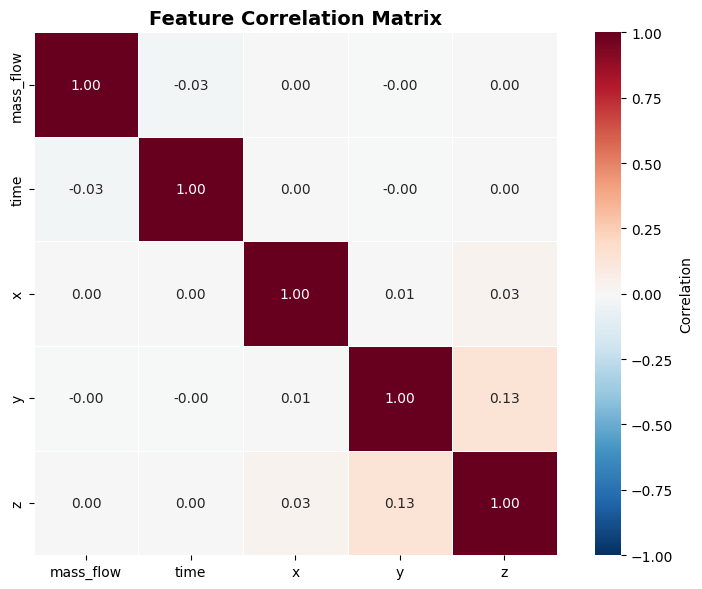

In [70]:
# Select features for correlation
features = ['mass_flow', 'time', 'x', 'y', 'z']
df_features = df[features]

# Calculate correlation matrix
corr_matrix = df_features.corr()

# Print correlation matrix
print("Correlation Matrix:")
print(corr_matrix.round(3))

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,           # Show correlation values
            fmt='.2f',            # 2 decimal places
            cmap='RdBu_r',        # Red-Blue diverging colormap
            center=0,             # Center at 0
            vmin=-1, vmax=1,      # Correlation range
            square=True,          # Square cells
            linewidths=0.5,       # Grid lines
            cbar_kws={'label': 'Correlation'},
            ax=ax)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

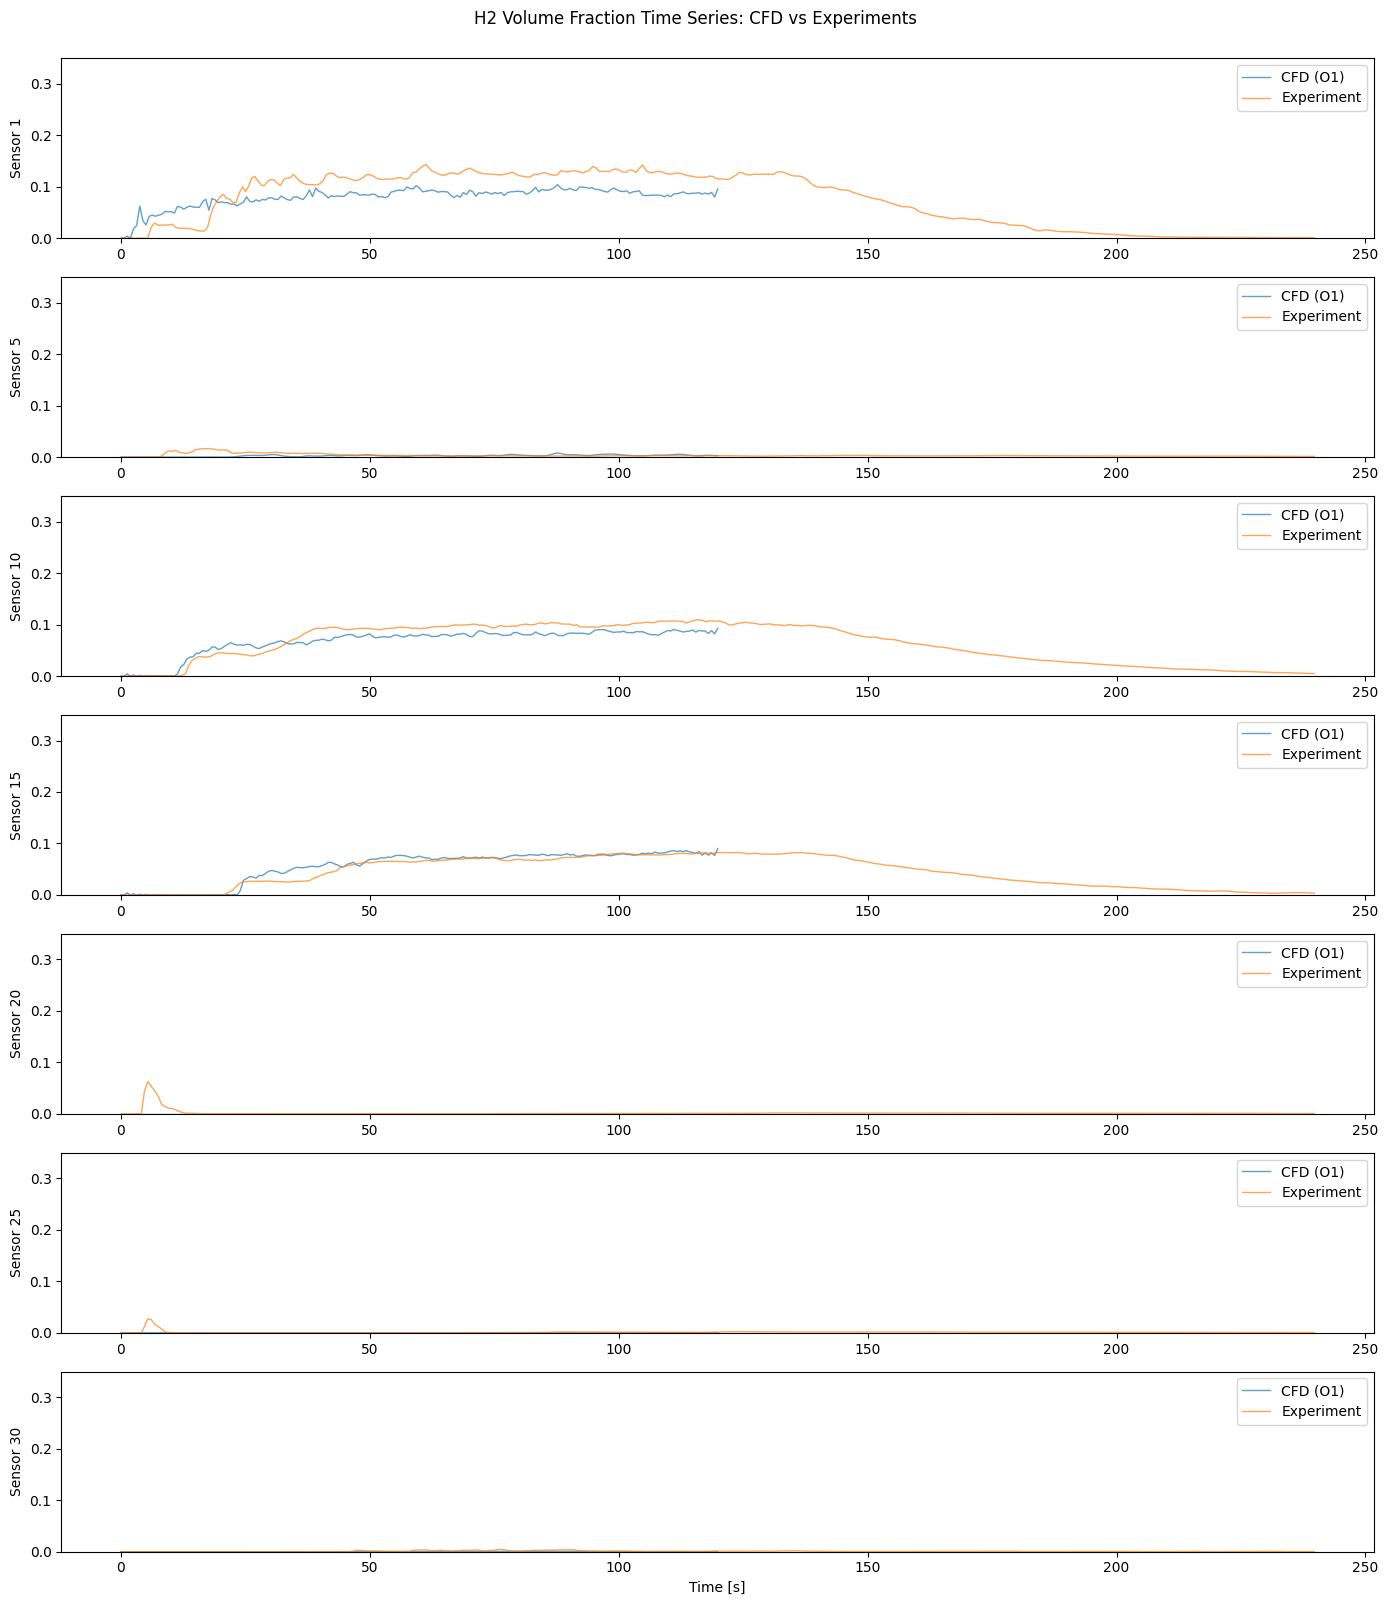

In [81]:
# Plot time series for a few sensors
sensor_ids = [1, 5, 10, 15, 20, 25, 30]
fig, axes = plt.subplots(len(sensor_ids), 1, figsize=(14, 16))

for idx, sensor_id in enumerate(sensor_ids):
    ax = axes[idx]
    
    # CFD data
    df_cfd_sensor = df[(df['source'] == 'cfd') & (df['scenario'] == 'O1') & 
                       (df['sensor_id'] == sensor_id)]
    if len(df_cfd_sensor) > 0:
        ax.plot(df_cfd_sensor['time'], df_cfd_sensor['h2_volume_fraction'], 
                label='CFD (O1)', alpha=0.7, linewidth=1)
    
    # Experimental data (reality gap)
    df_exp_sensor = df[(df['experiment_id'] == '23_FFI_P101_T00027') &
                       (df['sensor_id'] == sensor_id)]
    if len(df_exp_sensor) > 0:
        ax.plot(df_exp_sensor['time'], df_exp_sensor['h2_volume_fraction'], 
                label='Experiment', alpha=0.7, linewidth=1)
    
    ax.set_ylabel(f'Sensor {int(sensor_id)}')
    ax.legend()
    ax.set_ylim(0, 0.35)

axes[-1].set_xlabel('Time [s]')
plt.suptitle('H2 Volume Fraction Time Series: CFD vs Experiments', y=1.0)
plt.tight_layout()
plt.savefig(data_dir / 'time_series_comparison_scenario_O1.png', dpi=150)
plt.show()

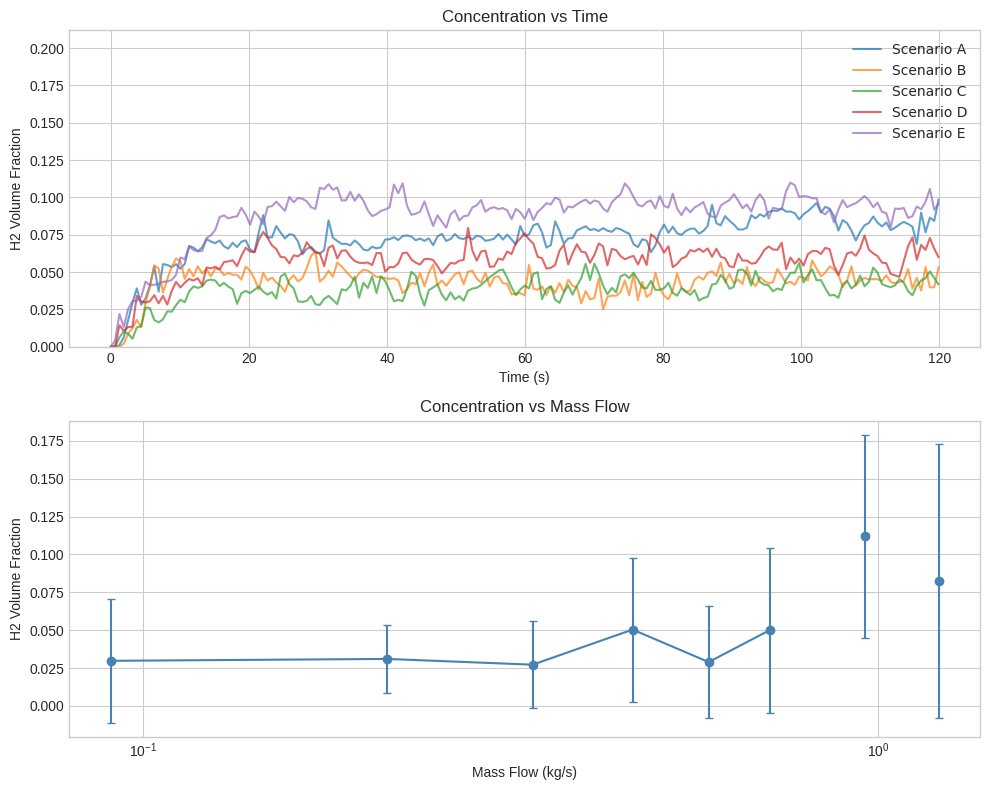


=== DATA SUMMARY ===
Total records: 296,665
Scenarios: 33
Sensors: 29
Time range: [0.0, 240.0] s
Mass flow range: [0.029, 1.270] kg/s
H2 concentration range: [0.0000, 0.3083]


In [94]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
# Fix font for H2 subscript
plt.rcParams['font.family'] = 'DejaVu Sans'
# 1. Concentration over Time
ax1 = axes[0]
for scenario in df['scenario'].unique()[:5]:  # Plot first 5 scenarios
    df_scen = df[df['scenario'] == scenario]
    # Sample one sensor per scenario
    sensor = df_scen['sensor_id'].iloc[0]
    df_sensor = df_scen[df_scen['sensor_id'] == sensor]
    ax1.plot(df_sensor['time'], df_sensor['h2_volume_fraction'], 
             label=f'Scenario {scenario}', alpha=0.7)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('H2 Volume Fraction')  # Fixed: no subscript
ax1.set_title('Concentration vs Time')
ax1.legend()
ax1.set_ylim(0, df['h2_volume_fraction'].quantile(0.99))


# 3. Concentration over Mass Flow
ax3 = axes[1]
# Bin mass flow for cleaner visualization
df['mass_flow_bin'] = pd.cut(df['mass_flow'], bins=10)
massflow_conc = df.groupby('mass_flow_bin', observed=False)['h2_volume_fraction'].agg(['mean', 'std'])
massflow_centers = [interval.mid for interval in massflow_conc.index]
ax3.errorbar(massflow_centers, massflow_conc['mean'], yerr=massflow_conc['std'],
            fmt='o-', capsize=3, color='steelblue')
ax3.set_xlabel('Mass Flow (kg/s)')
ax3.set_ylabel('H2 Volume Fraction')
ax3.set_title('Concentration vs Mass Flow')
ax3.set_xscale('log')

plt.tight_layout()
plt.savefig('data_analysis_overview.png', dpi=150, bbox_inches='tight')
plt.show()
# Summary statistics
print("\n=== DATA SUMMARY ===")
print(f"Total records: {len(df):,}")
print(f"Scenarios: {df['scenario'].nunique()}")
print(f"Sensors: {df['sensor_id'].nunique()}")
print(f"Time range: [{df['time'].min():.1f}, {df['time'].max():.1f}] s")
print(f"Mass flow range: [{df['mass_flow'].min():.3f}, {df['mass_flow'].max():.3f}] kg/s")
print(f"H2 concentration range: [{df['h2_volume_fraction'].min():.4f}, {df['h2_volume_fraction'].max():.4f}]")

Top (x,y) positions with multiple sensors:
  1. X≈0.6m, Y≈1.2m: 4 sensors, mass flows: [0.086      0.15       0.2        0.3        0.48       0.74
 1.         1.27       0.091      0.45       0.47577286 0.47833271
 0.46974408 0.32839189 0.72139255 0.56787114 0.5708861  1.2498731
 0.0792133  0.07918156 0.02917656 0.10135085 0.0879138  0.08578524
 0.4343846  0.43661481 1.22682068 0.09895282 0.09542988 0.48440685
 0.45314028 0.09271138]
  2. X≈0.6m, Y≈4.5m: 4 sensors, mass flows: [0.086      0.15       0.2        0.3        0.48       0.74
 1.         1.27       0.091      0.45       0.47577286 0.47833271
 0.46974408 0.32839189 0.72139255 0.56787114 0.5708861  1.2498731
 0.0792133  0.07918156 0.02917656 0.10135085 0.0879138  0.08578524
 0.4343846  0.43661481 1.22682068 0.09895282 0.09542988 0.48440685
 0.45314028 0.09271138]
  3. X≈0.6m, Y≈2.4m: 3 sensors, mass flows: [0.086      0.15       0.2        0.3        0.48       0.74
 1.         1.27       0.091      0.45       0.47577286 0.47

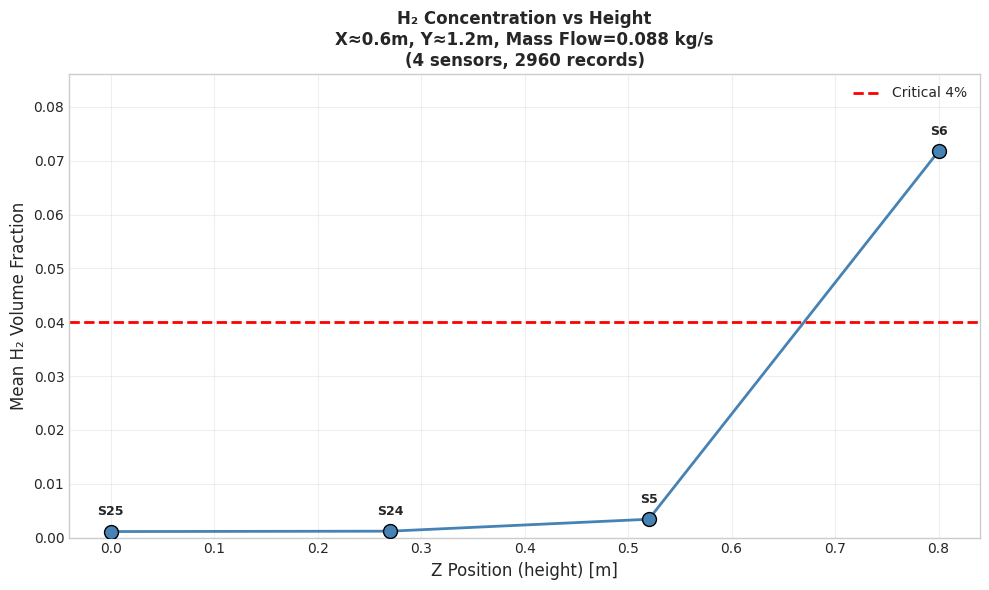


Plot saved!
Z range: 0.00m to 0.80m
Concentration range: 0.0011 to 0.0718

Sensor details:
   sensor_id     x     y     z      conc  n_records
3         25  0.47  1.10  0.00  0.001120        740
2         24  0.46  1.33  0.27  0.001189        740
0          5  0.48  1.33  0.52  0.003406        740
1          6  0.46  1.11  0.80  0.071763        740


In [87]:
# Load data
df = pd.read_csv('data/unified_raw.csv')

# Get unique sensor positions
sensor_pos = df[['sensor_id', 'x', 'y', 'z']].drop_duplicates().set_index('sensor_id')

# TOLERANCE for grouping nearby sensors (in meters)
TOLERANCE = 0.3

# Round x and y to group nearby positions
sensor_pos['x_rounded'] = (sensor_pos['x'] / TOLERANCE).round() * TOLERANCE
sensor_pos['y_rounded'] = (sensor_pos['y'] / TOLERANCE).round() * TOLERANCE

# Find (x, y) groups with multiple sensors and multiple mass flows
sensor_pos['xy_pair'] = list(zip(sensor_pos['x_rounded'], sensor_pos['y_rounded']))

# Check which (x,y) positions have data with consistent mass flows
xy_groups = []
for xy_pair in sensor_pos['xy_pair'].unique():
    mask = (sensor_pos['x_rounded'] == xy_pair[0]) & (sensor_pos['y_rounded'] == xy_pair[1])
    sensors = sensor_pos[mask].index.tolist()
    
    # Get mass flows for these sensors
    mass_flows = df[df['sensor_id'].isin(sensors)]['mass_flow'].unique()
    
    if len(sensors) > 1 and len(mass_flows) > 0:
        xy_groups.append({
            'xy': xy_pair,
            'sensors': sensors,
            'n_sensors': len(sensors),
            'mass_flows': mass_flows,
            'n_mass_flows': len(mass_flows)
        })

# Sort by number of sensors (descending)
xy_groups = sorted(xy_groups, key=lambda x: x['n_sensors'], reverse=True)

print(f"Top (x,y) positions with multiple sensors:")
for i, group in enumerate(xy_groups[:5]):
    print(f"  {i+1}. X≈{group['xy'][0]}m, Y≈{group['xy'][1]}m: "
          f"{group['n_sensors']} sensors, mass flows: {group['mass_flows']}")

# Choose the best group (most sensors with available mass flow data)
chosen_group = xy_groups[0]
fixed_x_rounded, fixed_y_rounded = chosen_group['xy']
sensors_at_xy = chosen_group['sensors']

print(f"\nChosen position: X≈{fixed_x_rounded}m, Y≈{fixed_y_rounded}m")
print(f"Available mass flows: {chosen_group['mass_flows']}")

# Choose the most common mass flow for this position
mass_flow_counts = df[df['sensor_id'].isin(sensors_at_xy)]['mass_flow'].value_counts()
chosen_mass_flow = mass_flow_counts.index[0]

print(f"Selected mass flow: {chosen_mass_flow:.3f} kg/s (most common, {mass_flow_counts.iloc[0]} records)")

# Filter data: same (x,y) tolerance AND same mass flow
filtered_df = df[
    (df['sensor_id'].isin(sensors_at_xy)) &
    (df['mass_flow'] == chosen_mass_flow)
]

print(f"\nFiltered data: {len(filtered_df)} records")

# Calculate mean concentration per sensor at this (x,y) and mass flow
plot_data = []
for sensor_id in sensors_at_xy:
    sensor_data = filtered_df[filtered_df['sensor_id'] == sensor_id]
    if len(sensor_data) > 0:
        mean_conc = sensor_data['h2_volume_fraction'].mean()
        z_pos = sensor_pos.loc[sensor_id, 'z']
        x_pos = sensor_pos.loc[sensor_id, 'x']
        y_pos = sensor_pos.loc[sensor_id, 'y']
        plot_data.append({
            'sensor_id': sensor_id, 
            'x': x_pos, 
            'y': y_pos, 
            'z': z_pos, 
            'conc': mean_conc,
            'n_records': len(sensor_data)
        })

plot_df = pd.DataFrame(plot_data).sort_values('z')

if len(plot_df) == 0:
    print("ERROR: No data found after filtering!")
else:
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot concentration vs z
    ax.plot(plot_df['z'], plot_df['conc'], 'o-', color='steelblue', 
            linewidth=2, markersize=10, markeredgecolor='black', zorder=3)

    # Add sensor ID labels
    for _, row in plot_df.iterrows():
        ax.annotate(f"S{int(row['sensor_id'])}", 
                   (row['z'], row['conc']),
                   textcoords="offset points",
                   xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

    # Critical threshold line (4% = 0.04)
    ax.axhline(y=0.04, color='red', linestyle='--', linewidth=2, label='Critical 4%', zorder=1)

    # Formatting
    ax.set_xlabel('Z Position (height) [m]', fontsize=12)
    ax.set_ylabel('Mean H₂ Volume Fraction', fontsize=12)
    ax.set_title(f'H₂ Concentration vs Height\nX≈{fixed_x_rounded}m, Y≈{fixed_y_rounded}m, Mass Flow={chosen_mass_flow:.3f} kg/s\n({len(plot_df)} sensors, {len(filtered_df)} records)', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend(loc='best')

    # Set y-axis limits
    y_max = max(plot_df['conc'].max() * 1.2, 0.05)
    ax.set_ylim(0, y_max)

    plt.tight_layout()
    plt.savefig('concentration_vs_z_fixed_xy_massflow.png', dpi=150)
    plt.show()

    print(f"\nPlot saved!")
    print(f"Z range: {plot_df['z'].min():.2f}m to {plot_df['z'].max():.2f}m")
    print(f"Concentration range: {plot_df['conc'].min():.4f} to {plot_df['conc'].max():.4f}")
    print(f"\nSensor details:")
    print(plot_df[['sensor_id', 'x', 'y', 'z', 'conc', 'n_records']])

Available (x,z) positions with multiple Y sensors:
  1. X≈0.44999999999999996m, Z≈0.75m: 5 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0.079', '0.029', '0.101', '0.088', '0.086', '0.434', '0.437', '1.227', '0.099', '0.095', '0.484', '0.453', '0.093']
  2. X≈0.44999999999999996m, Z≈0.44999999999999996m: 5 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0.079', '0.029', '0.101', '0.088', '0.086', '0.434', '0.437', '1.227', '0.099', '0.095', '0.484', '0.453', '0.093']
  3. X≈0.44999999999999996m, Z≈0.3m: 5 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0

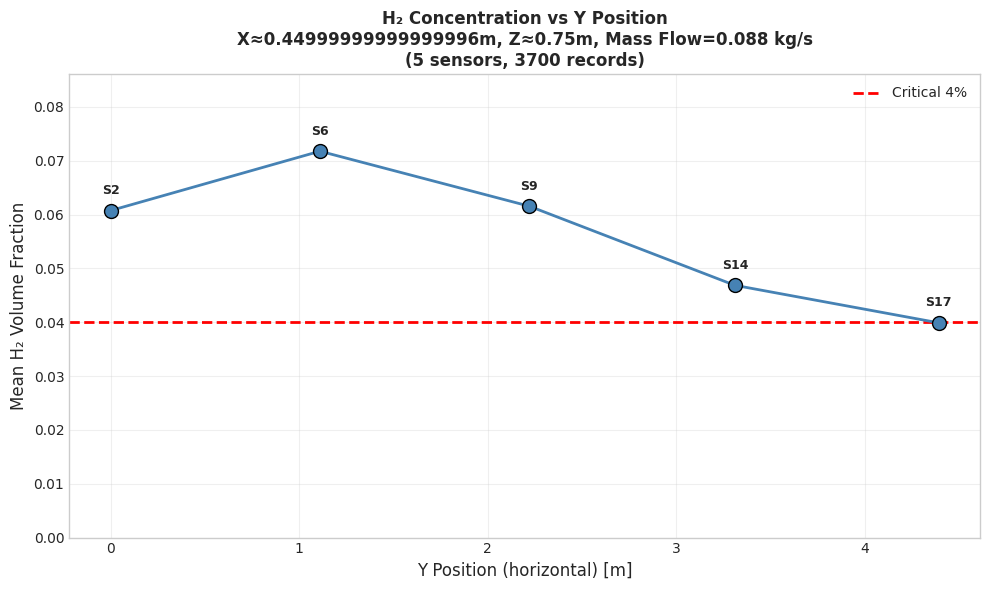


Plot saved!
Y range: 0.00m to 4.39m
Concentration range: 0.0399 to 0.0718

Sensor details:
   sensor_id     x     y    z      conc  n_records
0          2  0.46  0.00  0.8  0.060735        740
1          6  0.46  1.11  0.8  0.071763        740
2          9  0.46  2.22  0.8  0.061552        740
3         14  0.46  3.31  0.8  0.046855        740
4         17  0.46  4.39  0.8  0.039891        740


In [88]:
# Load data
df = pd.read_csv('data/unified_raw.csv')

# Get unique sensor positions
sensor_pos = df[['sensor_id', 'x', 'y', 'z']].drop_duplicates().set_index('sensor_id')

# TOLERANCE for grouping nearby sensors (in meters)
TOLERANCE = 0.15

# Round x and z to group nearby positions (we want to fix X and Z, vary Y)
sensor_pos['x_rounded'] = (sensor_pos['x'] / TOLERANCE).round() * TOLERANCE
sensor_pos['z_rounded'] = (sensor_pos['z'] / TOLERANCE).round() * TOLERANCE

# Find (x, z) groups that have multiple sensors (different y values)
sensor_pos['xz_pair'] = list(zip(sensor_pos['x_rounded'], sensor_pos['z_rounded']))

# Check which (x,z) positions have data with consistent mass flows
xz_groups = []
for xz_pair in sensor_pos['xz_pair'].unique():
    mask = (sensor_pos['x_rounded'] == xz_pair[0]) & (sensor_pos['z_rounded'] == xz_pair[1])
    sensors = sensor_pos[mask].index.tolist()
    
    # Get mass flows for these sensors
    mass_flows = df[df['sensor_id'].isin(sensors)]['mass_flow'].unique()
    
    if len(sensors) > 1 and len(mass_flows) > 0:
        xz_groups.append({
            'xz': xz_pair,
            'sensors': sensors,
            'n_sensors': len(sensors),
            'mass_flows': mass_flows,
            'n_mass_flows': len(mass_flows)
        })

# Sort by number of sensors (descending)
xz_groups = sorted(xz_groups, key=lambda x: x['n_sensors'], reverse=True)

print(f"Available (x,z) positions with multiple Y sensors:")
for i, group in enumerate(xz_groups[:5]):
    print(f"  {i+1}. X≈{group['xz'][0]}m, Z≈{group['xz'][1]}m: "
          f"{group['n_sensors']} sensors, mass flows: {[f'{mf:.3f}' for mf in group['mass_flows']]}")

if len(xz_groups) == 0:
    print("No (x,z) positions found with multiple Y sensors!")
    print("Try increasing TOLERANCE or check data...")
else:
    # Choose the best group
    chosen_group = xz_groups[0]
    fixed_x_rounded, fixed_z_rounded = chosen_group['xz']
    sensors_at_xz = chosen_group['sensors']

    print(f"\nChosen position: X≈{fixed_x_rounded}m, Z≈{fixed_z_rounded}m")
    print(f"Available mass flows: {[f'{mf:.3f}' for mf in chosen_group['mass_flows']]}")

    # Choose the most common mass flow
    mass_flow_counts = df[df['sensor_id'].isin(sensors_at_xz)]['mass_flow'].value_counts()
    chosen_mass_flow = mass_flow_counts.index[0]

    print(f"Selected mass flow: {chosen_mass_flow:.3f} kg/s (most common, {mass_flow_counts.iloc[0]} records)")

    # Filter data: same (x,z) tolerance AND same mass flow
    filtered_df = df[
        (df['sensor_id'].isin(sensors_at_xz)) &
        (df['mass_flow'] == chosen_mass_flow)
    ]

    print(f"\nFiltered data: {len(filtered_df)} records")

    # Calculate mean concentration per sensor
    plot_data = []
    for sensor_id in sensors_at_xz:
        sensor_data = filtered_df[filtered_df['sensor_id'] == sensor_id]
        if len(sensor_data) > 0:
            mean_conc = sensor_data['h2_volume_fraction'].mean()
            y_pos = sensor_pos.loc[sensor_id, 'y']
            x_pos = sensor_pos.loc[sensor_id, 'x']
            z_pos = sensor_pos.loc[sensor_id, 'z']
            plot_data.append({
                'sensor_id': sensor_id, 
                'x': x_pos, 
                'y': y_pos, 
                'z': z_pos, 
                'conc': mean_conc,
                'n_records': len(sensor_data)
            })

    plot_df = pd.DataFrame(plot_data).sort_values('y')

    if len(plot_df) == 0:
        print("ERROR: No data found after filtering!")
    else:
        # Create plot
        fig, ax = plt.subplots(figsize=(10, 6))

        # Plot concentration vs Y
        ax.plot(plot_df['y'], plot_df['conc'], 'o-', color='steelblue', 
                linewidth=2, markersize=10, markeredgecolor='black', zorder=3)

        # Add sensor ID labels
        for _, row in plot_df.iterrows():
            ax.annotate(f"S{int(row['sensor_id'])}", 
                       (row['y'], row['conc']),
                       textcoords="offset points",
                       xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

        # Critical threshold line (4% = 0.04)
        ax.axhline(y=0.04, color='red', linestyle='--', linewidth=2, label='Critical 4%', zorder=1)

        # Formatting
        ax.set_xlabel('Y Position (horizontal) [m]', fontsize=12)
        ax.set_ylabel('Mean H₂ Volume Fraction', fontsize=12)
        ax.set_title(f'H₂ Concentration vs Y Position\nX≈{fixed_x_rounded}m, Z≈{fixed_z_rounded}m, Mass Flow={chosen_mass_flow:.3f} kg/s\n({len(plot_df)} sensors, {len(filtered_df)} records)', 
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, zorder=0)
        ax.legend(loc='best')

        # Set y-axis limits
        y_max = max(plot_df['conc'].max() * 1.2, 0.05)
        ax.set_ylim(0, y_max)

        plt.tight_layout()
        plt.savefig('concentration_vs_y_fixed_xz_massflow.png', dpi=150)
        plt.show()

        print(f"\nPlot saved!")
        print(f"Y range: {plot_df['y'].min():.2f}m to {plot_df['y'].max():.2f}m")
        print(f"Concentration range: {plot_df['conc'].min():.4f} to {plot_df['conc'].max():.4f}")
        print(f"\nSensor details:")
        print(plot_df[['sensor_id', 'x', 'y', 'z', 'conc', 'n_records']])

Available (y,z) positions with multiple X sensors:
  1. Y≈2.25m, Z≈0.75m: 3 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0.079', '0.029', '0.101', '0.088', '0.086', '0.434', '0.437', '1.227', '0.099', '0.095', '0.484', '0.453', '0.093']
  2. Y≈0.3m, Z≈0.75m: 2 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0.079', '0.029', '0.101', '0.088', '0.086', '0.434', '0.437', '1.227', '0.099', '0.095', '0.484', '0.453', '0.093']
  3. Y≈2.4m, Z≈0.75m: 2 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0.079', '0.029', '0.101', '0.088', '0.086', '0.434', '0.437', 

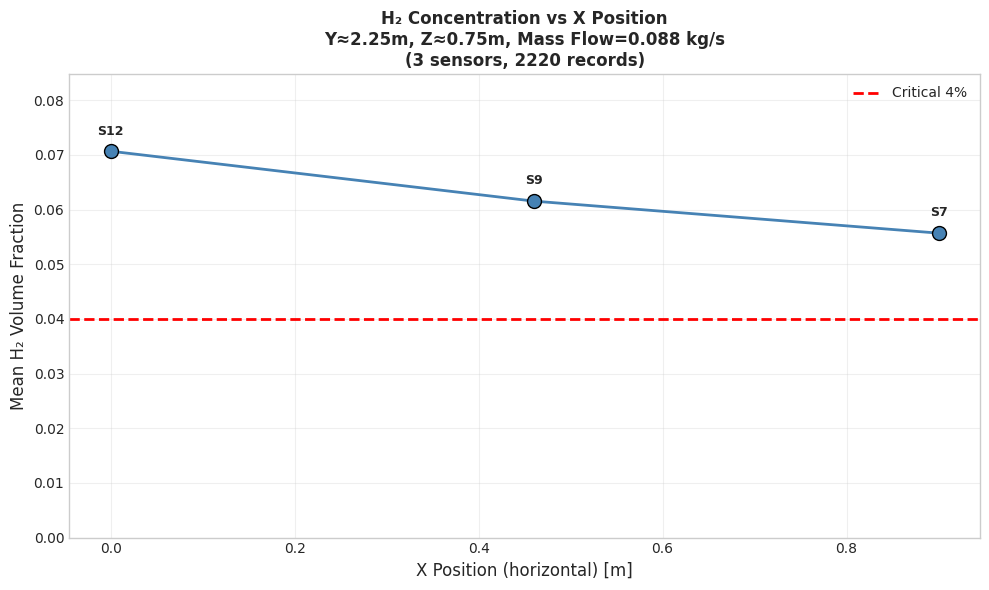


Plot saved!
X range: 0.00m to 0.90m
Concentration range: 0.0557 to 0.0707

Sensor details:
   sensor_id     x     y    z      conc  n_records
1         12  0.00  2.22  0.8  0.070682        740
0          9  0.46  2.22  0.8  0.061552        740
2          7  0.90  2.22  0.8  0.055694        740


In [89]:
# Load data
df = pd.read_csv('data/unified_raw.csv')

# Get unique sensor positions
sensor_pos = df[['sensor_id', 'x', 'y', 'z']].drop_duplicates().set_index('sensor_id')

# TOLERANCE for grouping nearby sensors (in meters)
TOLERANCE = 0.15

# Round y and z to group nearby positions (we want to fix Y and Z, vary X)
sensor_pos['y_rounded'] = (sensor_pos['y'] / TOLERANCE).round() * TOLERANCE
sensor_pos['z_rounded'] = (sensor_pos['z'] / TOLERANCE).round() * TOLERANCE

# Find (y, z) groups that have multiple sensors (different x values)
sensor_pos['yz_pair'] = list(zip(sensor_pos['y_rounded'], sensor_pos['z_rounded']))

# Check which (y,z) positions have data with consistent mass flows
yz_groups = []
for yz_pair in sensor_pos['yz_pair'].unique():
    mask = (sensor_pos['y_rounded'] == yz_pair[0]) & (sensor_pos['z_rounded'] == yz_pair[1])
    sensors = sensor_pos[mask].index.tolist()
    
    # Get mass flows for these sensors
    mass_flows = df[df['sensor_id'].isin(sensors)]['mass_flow'].unique()
    
    if len(sensors) > 1 and len(mass_flows) > 0:
        yz_groups.append({
            'yz': yz_pair,
            'sensors': sensors,
            'n_sensors': len(sensors),
            'mass_flows': mass_flows,
            'n_mass_flows': len(mass_flows)
        })

# Sort by number of sensors (descending)
yz_groups = sorted(yz_groups, key=lambda x: x['n_sensors'], reverse=True)

print(f"Available (y,z) positions with multiple X sensors:")
for i, group in enumerate(yz_groups[:5]):
    print(f"  {i+1}. Y≈{group['yz'][0]}m, Z≈{group['yz'][1]}m: "
          f"{group['n_sensors']} sensors, mass flows: {[f'{mf:.3f}' for mf in group['mass_flows']]}")

if len(yz_groups) == 0:
    print("No (y,z) positions found with multiple X sensors!")
    print("Try increasing TOLERANCE or check data...")
else:
    # Choose the best group
    chosen_group = yz_groups[0]
    fixed_y_rounded, fixed_z_rounded = chosen_group['yz']
    sensors_at_yz = chosen_group['sensors']

    print(f"\nChosen position: Y≈{fixed_y_rounded}m, Z≈{fixed_z_rounded}m")
    print(f"Available mass flows: {[f'{mf:.3f}' for mf in chosen_group['mass_flows']]}")

    # Choose the most common mass flow
    mass_flow_counts = df[df['sensor_id'].isin(sensors_at_yz)]['mass_flow'].value_counts()
    chosen_mass_flow = mass_flow_counts.index[0]

    print(f"Selected mass flow: {chosen_mass_flow:.3f} kg/s (most common, {mass_flow_counts.iloc[0]} records)")

    # Filter data: same (y,z) tolerance AND same mass flow
    filtered_df = df[
        (df['sensor_id'].isin(sensors_at_yz)) &
        (df['mass_flow'] == chosen_mass_flow)
    ]

    print(f"\nFiltered data: {len(filtered_df)} records")

    # Calculate mean concentration per sensor
    plot_data = []
    for sensor_id in sensors_at_yz:
        sensor_data = filtered_df[filtered_df['sensor_id'] == sensor_id]
        if len(sensor_data) > 0:
            mean_conc = sensor_data['h2_volume_fraction'].mean()
            x_pos = sensor_pos.loc[sensor_id, 'x']
            y_pos = sensor_pos.loc[sensor_id, 'y']
            z_pos = sensor_pos.loc[sensor_id, 'z']
            plot_data.append({
                'sensor_id': sensor_id, 
                'x': x_pos, 
                'y': y_pos, 
                'z': z_pos, 
                'conc': mean_conc,
                'n_records': len(sensor_data)
            })

    plot_df = pd.DataFrame(plot_data).sort_values('x')

    if len(plot_df) == 0:
        print("ERROR: No data found after filtering!")
    else:
        # Create plot
        fig, ax = plt.subplots(figsize=(10, 6))

        # Plot concentration vs X
        ax.plot(plot_df['x'], plot_df['conc'], 'o-', color='steelblue', 
                linewidth=2, markersize=10, markeredgecolor='black', zorder=3)

        # Add sensor ID labels
        for _, row in plot_df.iterrows():
            ax.annotate(f"S{int(row['sensor_id'])}", 
                       (row['x'], row['conc']),
                       textcoords="offset points",
                       xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

        # Critical threshold line (4% = 0.04)
        ax.axhline(y=0.04, color='red', linestyle='--', linewidth=2, label='Critical 4%', zorder=1)

        # Formatting
        ax.set_xlabel('X Position (horizontal) [m]', fontsize=12)
        ax.set_ylabel('Mean H₂ Volume Fraction', fontsize=12)
        ax.set_title(f'H₂ Concentration vs X Position\nY≈{fixed_y_rounded}m, Z≈{fixed_z_rounded}m, Mass Flow={chosen_mass_flow:.3f} kg/s\n({len(plot_df)} sensors, {len(filtered_df)} records)', 
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, zorder=0)
        ax.legend(loc='best')

        # Set y-axis limits
        y_max = max(plot_df['conc'].max() * 1.2, 0.05)
        ax.set_ylim(0, y_max)

        plt.tight_layout()
        plt.savefig('concentration_vs_x_fixed_yz_massflow.png', dpi=150)
        plt.show()

        print(f"\nPlot saved!")
        print(f"X range: {plot_df['x'].min():.2f}m to {plot_df['x'].max():.2f}m")
        print(f"Concentration range: {plot_df['conc'].min():.4f} to {plot_df['conc'].max():.4f}")
        print(f"\nSensor details:")
        print(plot_df[['sensor_id', 'x', 'y', 'z', 'conc', 'n_records']])

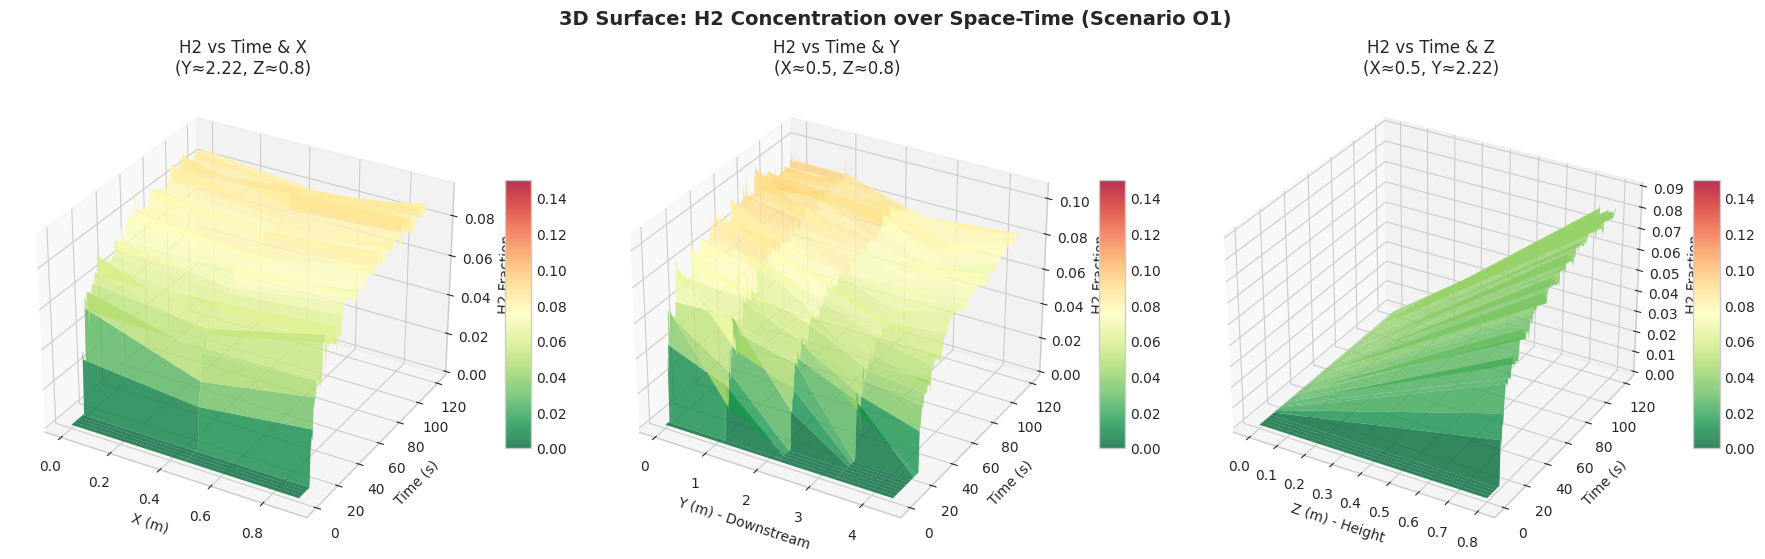

In [65]:
# Select scenario
scenario = 'O1'
df_scen = df[df['scenario'] == scenario]

fig = plt.figure(figsize=(18, 6))

# 1. H2 surface over Time and X
ax1 = fig.add_subplot(131, projection='3d')
y_fix, z_fix = 2.22, 0.8
tol = 0.2

df_tx = df_scen[
    (np.abs(df_scen['y'] - y_fix) < tol) & 
    (np.abs(df_scen['z'] - z_fix) < tol)
]

if len(df_tx) > 0:
    pivot = df_tx.pivot_table(values='h2_volume_fraction', index='time', columns='x', aggfunc='mean')
    X, T = np.meshgrid(pivot.columns.values, pivot.index.values)
    Z = pivot.values
    
    surf1 = ax1.plot_surface(X, T, Z, cmap='RdYlGn_r', alpha=0.8, 
                            vmin=0, vmax=0.15, edgecolor='none')
    ax1.set_xlabel('X (m)')
    ax1.set_ylabel('Time (s)')
    ax1.set_zlabel('H2 Fraction')
    ax1.set_title(f'H2 vs Time & X\n(Y≈{y_fix}, Z≈{z_fix})')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# 2. H2 surface over Time and Y
ax2 = fig.add_subplot(132, projection='3d')
x_fix, z_fix = 0.5, 0.8

df_ty = df_scen[
    (np.abs(df_scen['x'] - x_fix) < tol) & 
    (np.abs(df_scen['z'] - z_fix) < tol)
]

if len(df_ty) > 0:
    pivot = df_ty.pivot_table(values='h2_volume_fraction', index='time', columns='y', aggfunc='mean')
    Y, T = np.meshgrid(pivot.columns.values, pivot.index.values)
    Z = pivot.values
    
    surf2 = ax2.plot_surface(Y, T, Z, cmap='RdYlGn_r', alpha=0.8,
                            vmin=0, vmax=0.15, edgecolor='none')
    ax2.set_xlabel('Y (m) - Downstream')
    ax2.set_ylabel('Time (s)')
    ax2.set_zlabel('H2 Fraction')
    ax2.set_title(f'H2 vs Time & Y\n(X≈{x_fix}, Z≈{z_fix})')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

# 3. H2 surface over Time and Z
ax3 = fig.add_subplot(133, projection='3d')
x_fix, y_fix = 0.5, 2.22

df_tz = df_scen[
    (np.abs(df_scen['x'] - x_fix) < tol) & 
    (np.abs(df_scen['y'] - y_fix) < tol)
]

if len(df_tz) > 0:
    pivot = df_tz.pivot_table(values='h2_volume_fraction', index='time', columns='z', aggfunc='mean')
    Z_pos, T = np.meshgrid(pivot.columns.values, pivot.index.values)
    H2 = pivot.values
    
    surf3 = ax3.plot_surface(Z_pos, T, H2, cmap='RdYlGn_r', alpha=0.8,
                            vmin=0, vmax=0.15, edgecolor='none')
    ax3.set_xlabel('Z (m) - Height')
    ax3.set_ylabel('Time (s)')
    ax3.set_zlabel('H2 Fraction')
    ax3.set_title(f'H2 vs Time & Z\n(X≈{x_fix}, Y≈{y_fix})')
    fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)

plt.suptitle(f'3D Surface: H2 Concentration over Space-Time (Scenario {scenario})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('h2_spacetime_3d_surface.png', dpi=150, bbox_inches='tight')
plt.show()


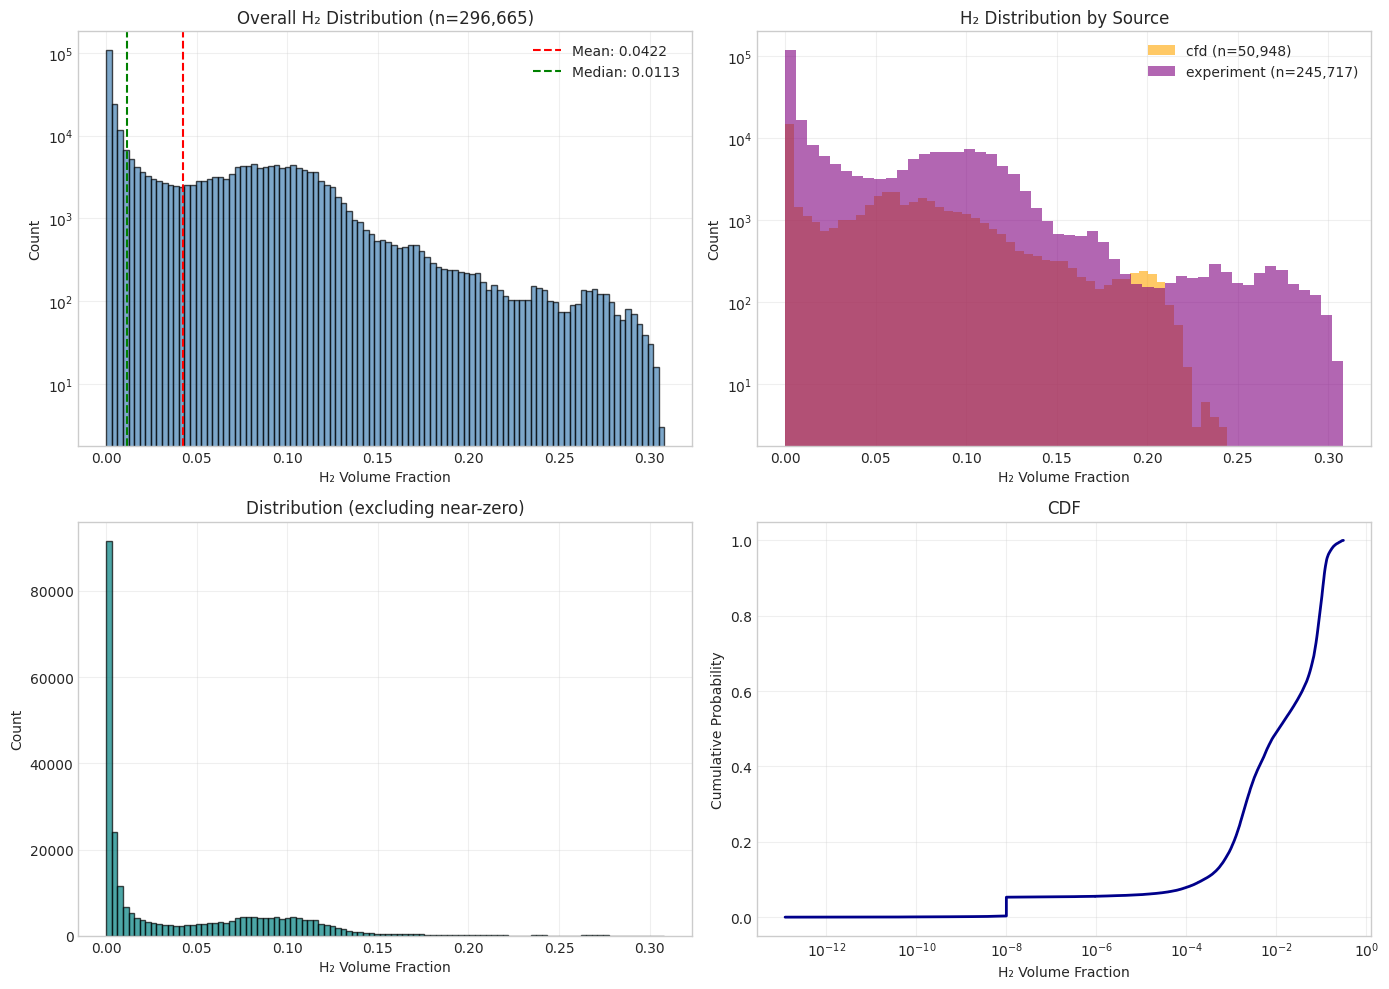

count    2.966650e+05
mean     4.215154e-02
std      5.203003e-02
min      1.211063e-13
25%      1.573871e-03
50%      1.129484e-02
75%      8.063445e-02
max      3.082763e-01
Name: h2_volume_fraction, dtype: float64


In [84]:
# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall distribution
ax = axes[0, 0]
ax.hist(df['h2_volume_fraction'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('H₂ Volume Fraction')
ax.set_ylabel('Count')
ax.set_title(f'Overall H₂ Distribution (n={len(df):,})')
ax.set_yscale('log')
ax.axvline(df['h2_volume_fraction'].mean(), color='red', linestyle='--', label=f"Mean: {df['h2_volume_fraction'].mean():.4f}")
ax.axvline(df['h2_volume_fraction'].median(), color='green', linestyle='--', label=f"Median: {df['h2_volume_fraction'].median():.4f}")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. By source
ax = axes[0, 1]
for source, color in [('cfd', 'orange'), ('experiment', 'purple')]:
    data = df[df['source'] == source]['h2_volume_fraction']
    ax.hist(data, bins=50, alpha=0.6, label=f'{source} (n={len(data):,})', color=color)
ax.set_xlabel('H₂ Volume Fraction')
ax.set_ylabel('Count')
ax.set_title('H₂ Distribution by Source')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Exclude near-zero
ax = axes[1, 0]
df_nonzero = df[df['h2_volume_fraction'] > 1e-6]
ax.hist(df_nonzero['h2_volume_fraction'], bins=100, color='teal', edgecolor='black', alpha=0.7)
ax.set_xlabel('H₂ Volume Fraction')
ax.set_ylabel('Count')
ax.set_title(f'Distribution (excluding near-zero)')
ax.grid(True, alpha=0.3)

# 4. CDF
ax = axes[1, 1]
sorted_data = np.sort(df['h2_volume_fraction'])
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
ax.plot(sorted_data, cdf, color='darkblue', linewidth=2)
ax.set_xlabel('H₂ Volume Fraction')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('h2_histogram.png', dpi=150)
plt.show()

# Print statistics
print(df['h2_volume_fraction'].describe())

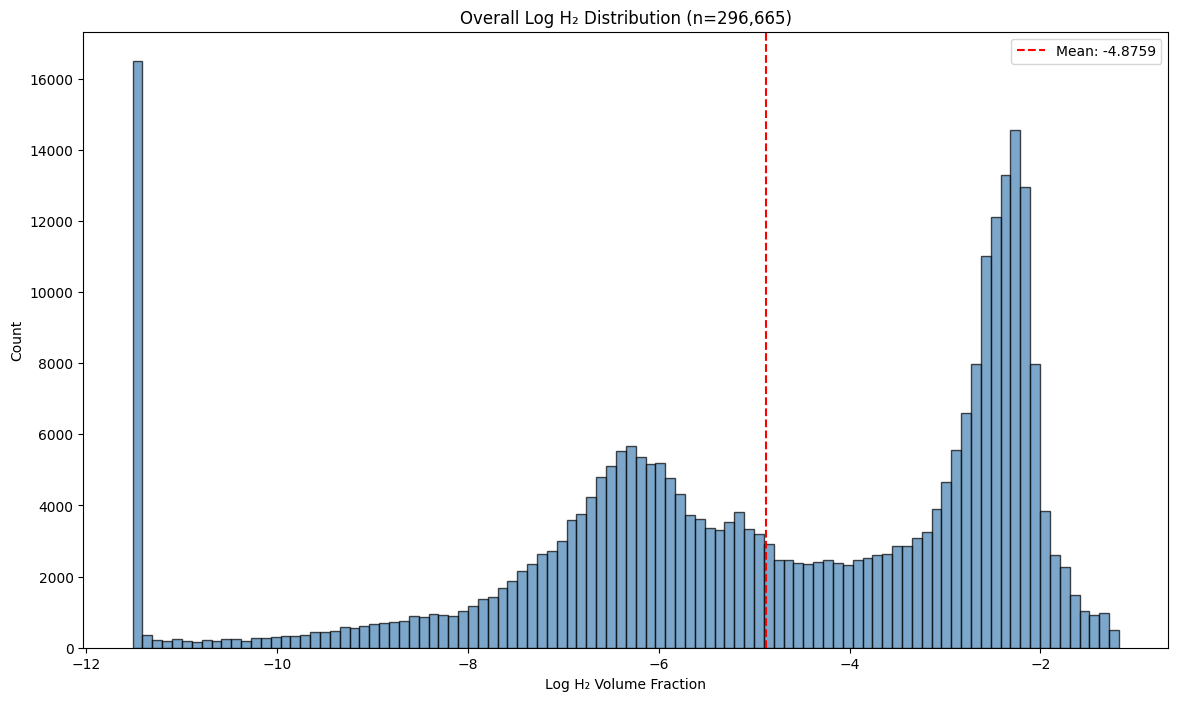

In [33]:
# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

log_h2_all = np.log(df['h2_volume_fraction'] + 1e-5)
# 1. Overall distribution
ax.hist(log_h2_all, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Log H₂ Volume Fraction')
ax.set_ylabel('Count')
ax.set_title(f'Overall Log H₂ Distribution (n={len(df):,})')
ax.axvline(log_h2_all.mean(), color='red', linestyle='--', label=f"Mean: {log_h2_all.mean():.4f}")
ax.legend()

plt.show()